In [20]:
import glob
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [21]:
# ==========================================
# 1. Global Configuration
# ==========================================
config = {
    "task_time": 16,  # タスク時間（分）
    "tri_threshold": 4,  # 刺激検出のしきい値
    "tri_start_point": 2,  # 刺激開始とみなすカウント数
    "tri_end_point": 19,  # 刺激終了とみなすカウント数
    "window_size": 1000,
}

In [22]:
# ==========================================
# 2. Function Definitions
# ==========================================


def process_bin_file(bin_path, config):
    """
    Loads a binary file, detects stimulation events, and downsamples data to 1Hz.

    The time axis is automatically synchronized and calculated within the
    DataFrame.
    """
    # 2-1. Load Binary Data
    num_raw = config["task_time"] * 60 * 1000

    with open(bin_path, "rb") as f:
        raw_data = np.frombuffer(f.read(), dtype=np.float64).reshape(-1, 4)[
            :num_raw
        ]

    if len(raw_data) != num_raw:
        print(f"Number of data points does not match task duration: {bin_path}")
        return None

    isoTri = raw_data[:, 0]
    greenTri = raw_data[:, 1]
    floData = raw_data[:, 2]
    original_time = np.arange(1, num_raw + 1) / 1000  # 秒に変換

   # 2-2. Helper Function for Stimulation Event Detection
    def _detect(signal):
        threshold = config["tri_threshold"]
        start_point = config["tri_start_point"]
        end_point = config["tri_end_point"]

        logi = np.zeros_like(signal, dtype=int)
        count = 0
        for i, val in enumerate(signal):
            if val >= threshold:
                count += 1
                logi[i] = 1 if start_point < count < end_point else 0
            else:
                count = 0
        start_indices = np.where(np.diff(logi) == 1)[0] + 1
        end_indices = np.where(np.diff(logi) == -1)[0] + 1
        return start_indices, end_indices

    isoStartInd, isoEndInd = _detect(isoTri)
    greenStartInd, greenEndInd = _detect(greenTri)

    # 2-3. Extract Mean Values for Each Event Interval
    isoMean = [
        np.mean(floData[start:end]) for start, end in zip(isoStartInd, isoEndInd)
    ]
    greenMean = [
        np.mean(floData[start:end])
        for start, end in zip(greenStartInd, greenEndInd)
    ]
    greenMeanTime = [
        np.mean(original_time[start:end])
        for start, end in zip(greenStartInd, greenEndInd)
    ]

    min_length = min(len(isoMean), len(greenMean))
    isoMean, greenMean, greenMeanTime = (
        isoMean[:min_length],
        greenMean[:min_length],
        greenMeanTime[:min_length],
    )

    # 2-4. Downsample to 1Hz (Block Averaging)
    def _downsample(data):
        arr = np.array(data)
        n = len(arr) // 20
        return arr[: n * 20].reshape(n, 20).mean(axis=1)

    isoMovingAve = _downsample(isoMean)
    greenMovingAve = _downsample(greenMean)
    timeMovingAve = _downsample(greenMeanTime)

   # Return a DataFrame containing the synchronized time axis
    return pd.DataFrame({"time": timeMovingAve, "iso": isoMovingAve, "green": greenMovingAve}    )

def dFF_func( df_mouse, BC_start_sec, BC_end_sec, BL_start_sec, BL_end_sec, fitting, mouse):
    """Computes dFF for a specific subject and generates a 3-panel plot."""
    time = df_mouse["time"].to_numpy()
    iso = df_mouse["iso"].to_numpy()
    green = df_mouse["green"].to_numpy()

    min_length = min(len(time), len(iso))
    time, iso, green = time[:min_length], iso[:min_length], green[:min_length]

    # Search for indices closest to the specified time targets
    BC_start_idx = np.argmin(np.abs(time - BC_start_sec))
    BC_end_idx = np.argmin(np.abs(time - BC_end_sec))
    BL_start_idx = np.argmin(np.abs(time - BL_start_sec))
    BL_end_idx = np.argmin(np.abs(time - BL_end_sec))

    # Baseline Correction for isosbestic data (Linear Fitting)
    fit_iso = np.polyfit(
        time[BC_start_idx:BC_end_idx], iso[BC_start_idx:BC_end_idx], 1
    )
    fittedIso = fit_iso[0] * time + fit_iso[1]
    isoBCN = (iso - fittedIso) + 1

   # Baseline Correction for green data
    fit_green = np.polyfit(
        time[BC_start_idx:BC_end_idx], green[BC_start_idx:BC_end_idx], 1
    )
    fittedGreen = fit_green[0] * time + fit_green[1]
    
    # Conditional branching based on the fitting parameter
    if fitting == 1:
        greenBC = green - fittedGreen
    else:
        greenBC = green - fittedIso
    greenBCN = greenBC + 1

    # Ratiometric dFF calculation and zero-centering against baseline
    dFF = greenBCN / isoBCN
    BL_mean = np.mean(dFF[BL_start_idx:BL_end_idx])
    dFF_result = dFF - BL_mean

    # --- Plotting Figures ---
    plt.figure(figsize=(40, 4))
    plt.subplots_adjust(wspace=0.4, hspace=0.4)

    # Panel 1: Raw Signals & Fitting Lines
    plt.subplot(1, 3, 1)
    plt.plot(time, iso, color="gray", label="iso")
    plt.plot(time, green, color="black", label="green")
    if fitting == 1:
        plt.plot( time[BC_start_idx:BC_end_idx],
            green[BC_start_idx:BC_end_idx],
            color="red",)
        plt.plot(time, fittedGreen, color="blue", label="fitted green")
    else:
        plt.plot(time, fittedIso, color="blue", label="fitted iso")
    plt.title(f"{mouse}")

    # Panel 2: Baseline Corrected Signals (BCN)
    plt.subplot(1, 3, 2)
    plt.plot(time, isoBCN, color="gray")
    plt.plot(time, greenBCN, color="black")
    plt.title("Baseline Corrected (BCN)")

    # Panel 3: Final dFF Output
    plt.subplot(1, 3, 3)
    plt.plot(time, dFF_result, color="tab:green")
    plt.plot(
        time[BL_start_idx:BL_end_idx],
        dFF_result[BL_start_idx:BL_end_idx],
        color="red",
    )
    plt.title("dF/F")
    plt.show()

    return dFF_result


In [23]:
# ==========================================
# 3. File Path Retrieval & Preprocessing Loop
# ==========================================
iLacco_path = "C:/Users/Astrocyte/Desktop/BW_FiberPhotometry/Data/20261002_iLacco_airPuff_iBARK_final/*"
iLacco_filePath = sorted(glob.glob(iLacco_path))

D110A_iLacco_File = [
    file for file in iLacco_filePath if "iLacco_control" in file
]
iBARK_iLacco_File = [
    file for file in iLacco_filePath if "iLacco_ibARK" in file
]

# Automatically generate dictionaries mapped to mouse IDs
D110A_iLacco_Files = {f"D110A_{idx}": [f for f in D110A_iLacco_File if f"_{idx}." in f][0]
    for idx in ["01","03","04","05","06","07", "09", "10"]
    if any(f"_{idx}." in f for f in D110A_iLacco_File)}




iBARK_iLacco_Files = {f"iBARK_{idx}": [f for f in iBARK_iLacco_File if f"_{idx}." in f][0]
    for idx in ["01", "02", "03", "04", "05", "06", "08","09", "10"]
    if any(f"_{idx}." in f for f in iBARK_iLacco_File)}


# --- Batch Preprocessing for D110A Group ---
D110A_iLacco_movingAve_dict = {}
for mouse_name, bin_file in D110A_iLacco_Files.items():
    df = process_bin_file(bin_file, config)
    if df is not None:
        D110A_iLacco_movingAve_dict[mouse_name] = df
        print(f"Preprocessed: {mouse_name}")

# --- Batch Preprocessing for iBARK Group ---
iBARK_iLacco_movingAve_dict = {}
for mouse_name, bin_file in iBARK_iLacco_Files.items():
    df = process_bin_file(bin_file, config)
    if df is not None:
        iBARK_iLacco_movingAve_dict[mouse_name] = df
        print(f"Preprocessed: {mouse_name}")



Preprocessed: D110A_01
Preprocessed: D110A_03
Preprocessed: D110A_04
Preprocessed: D110A_05
Preprocessed: D110A_06
Preprocessed: D110A_07
Preprocessed: D110A_09
Preprocessed: D110A_10
Preprocessed: iBARK_01
Preprocessed: iBARK_02
Preprocessed: iBARK_03
Preprocessed: iBARK_04
Preprocessed: iBARK_05
Preprocessed: iBARK_06
Preprocessed: iBARK_08
Preprocessed: iBARK_09
Preprocessed: iBARK_10


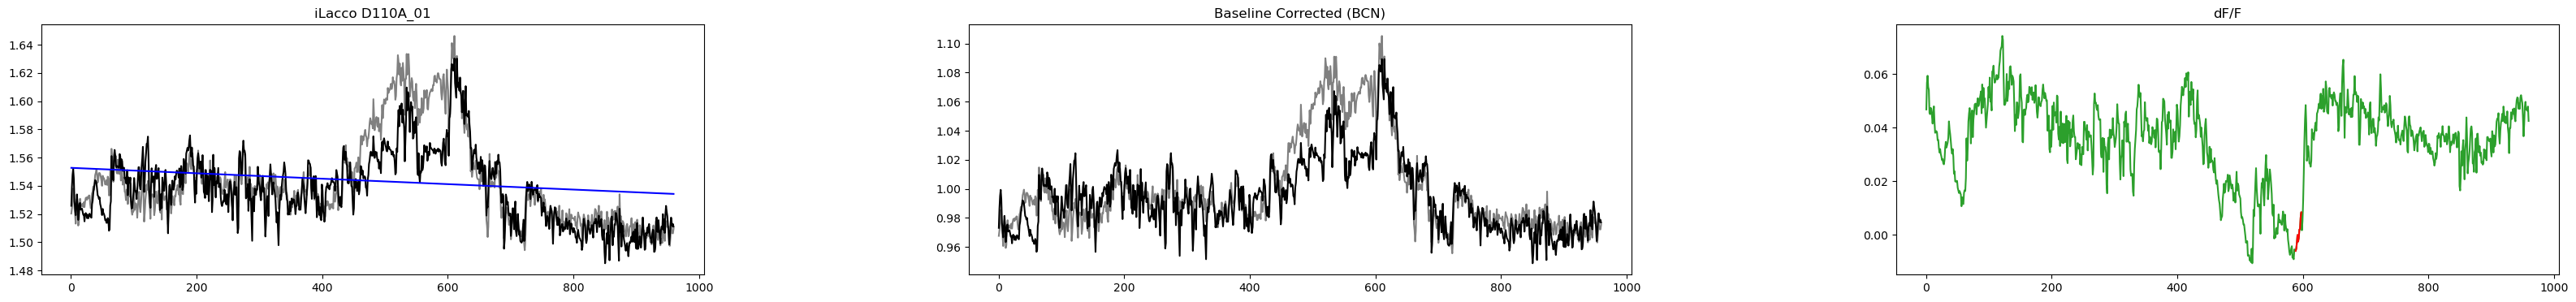

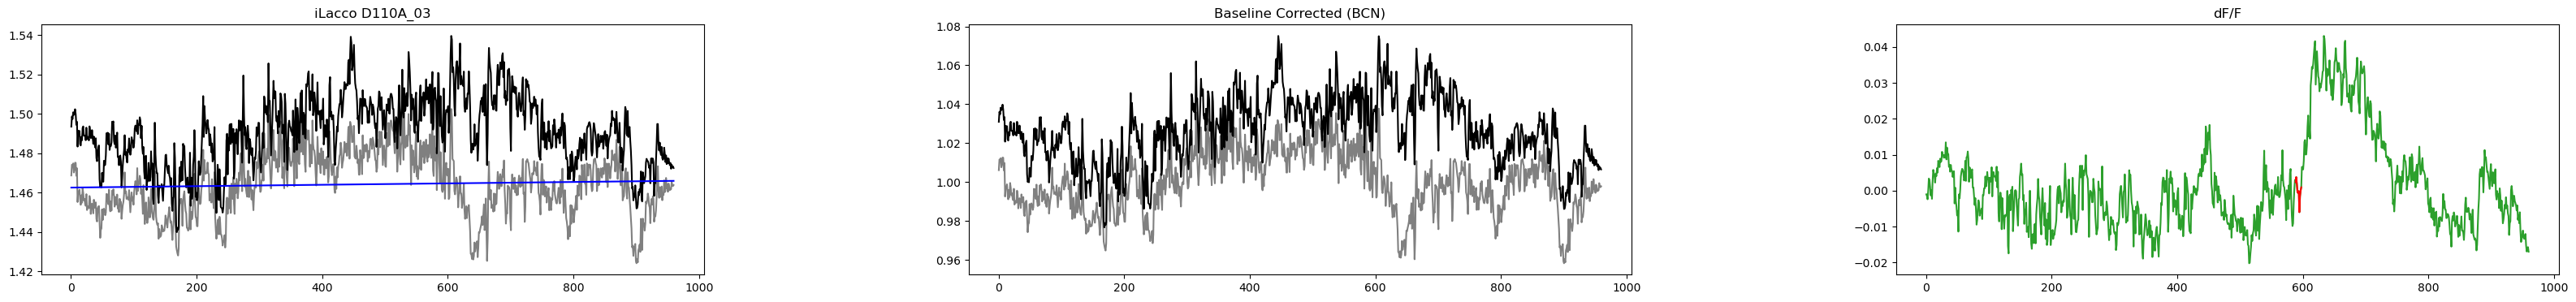

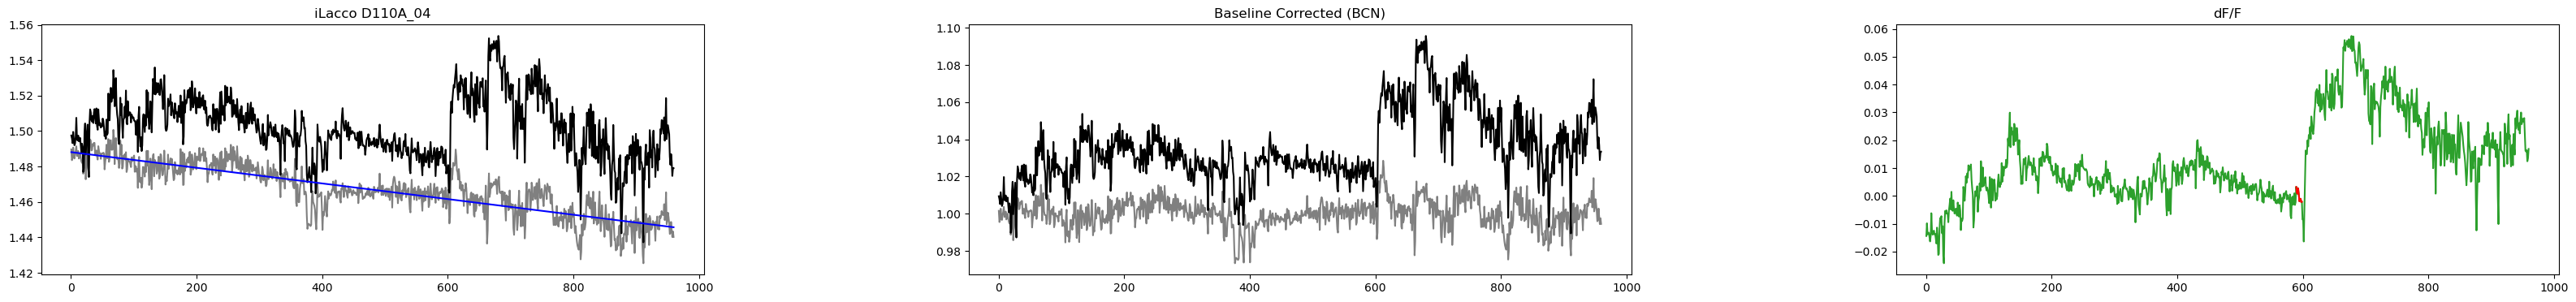

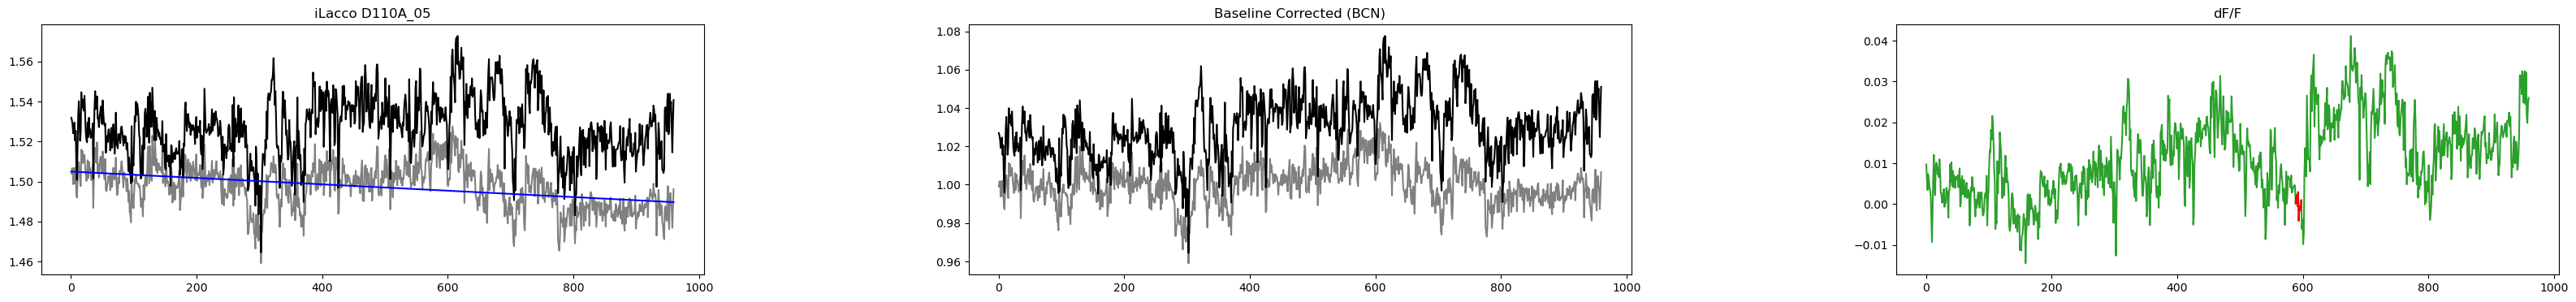

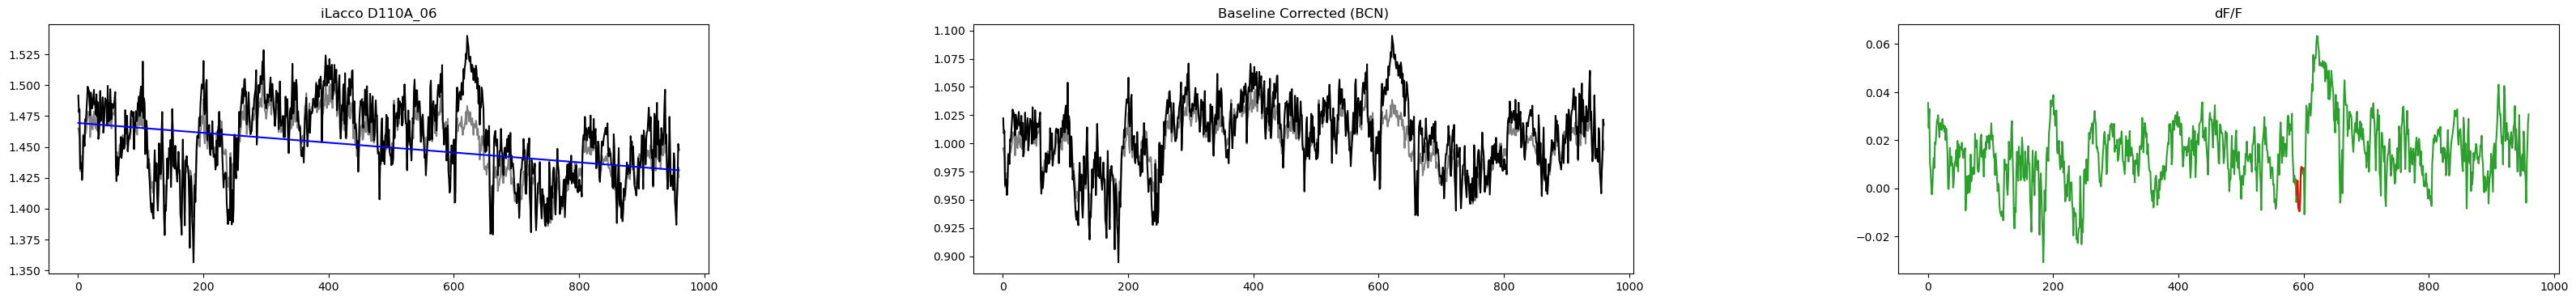

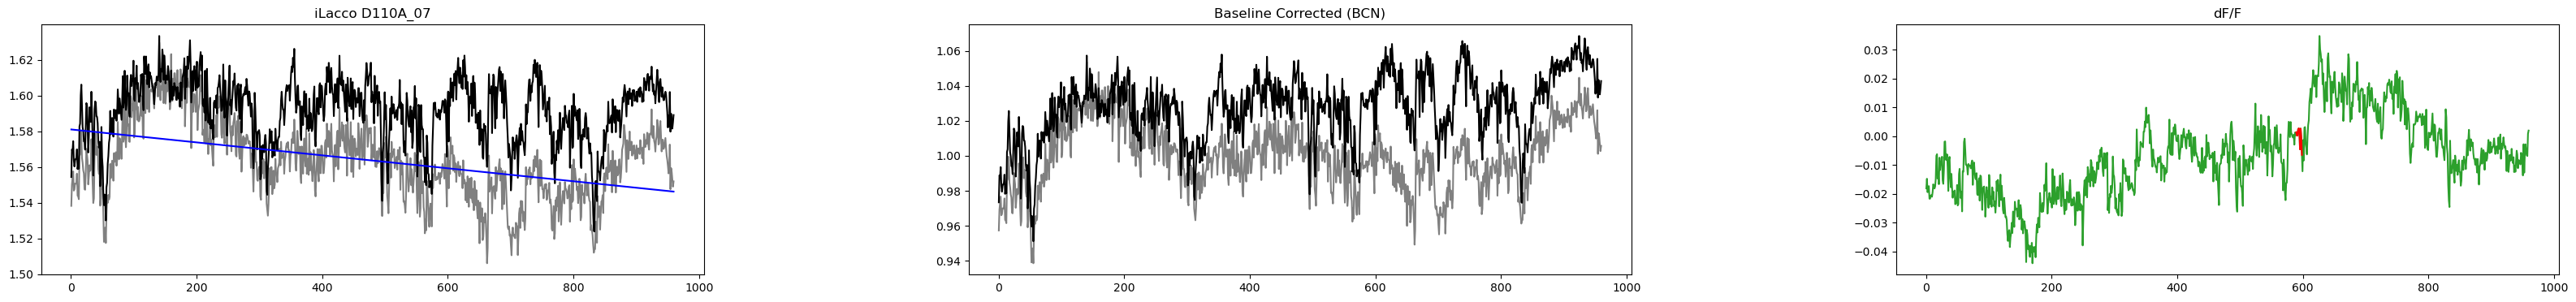

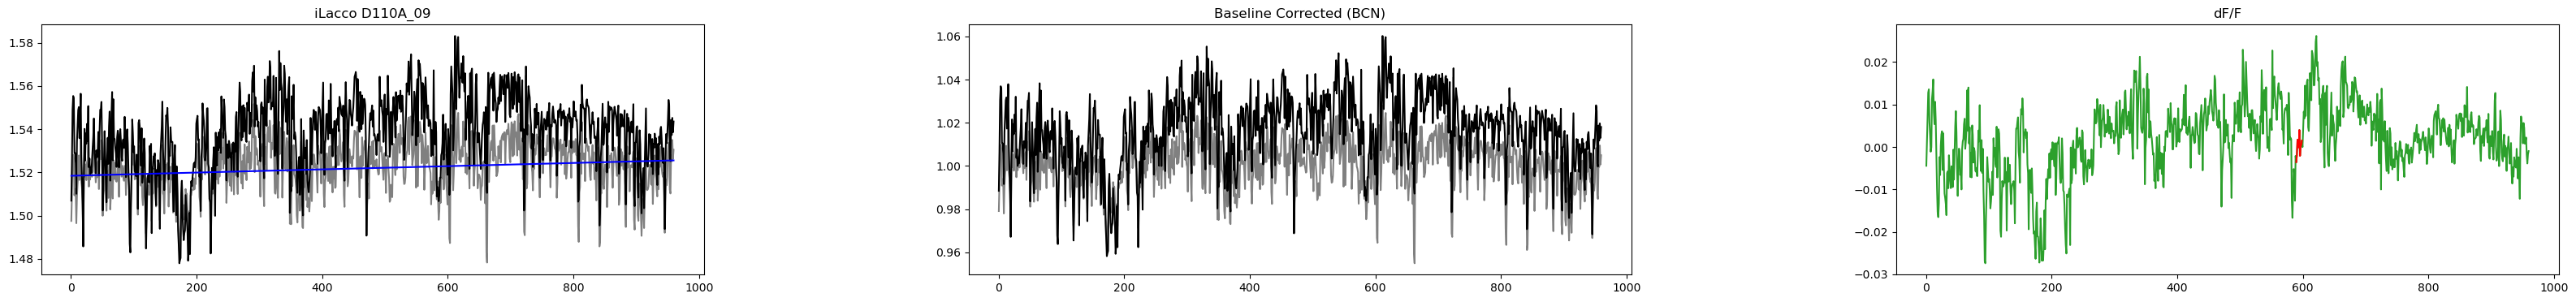

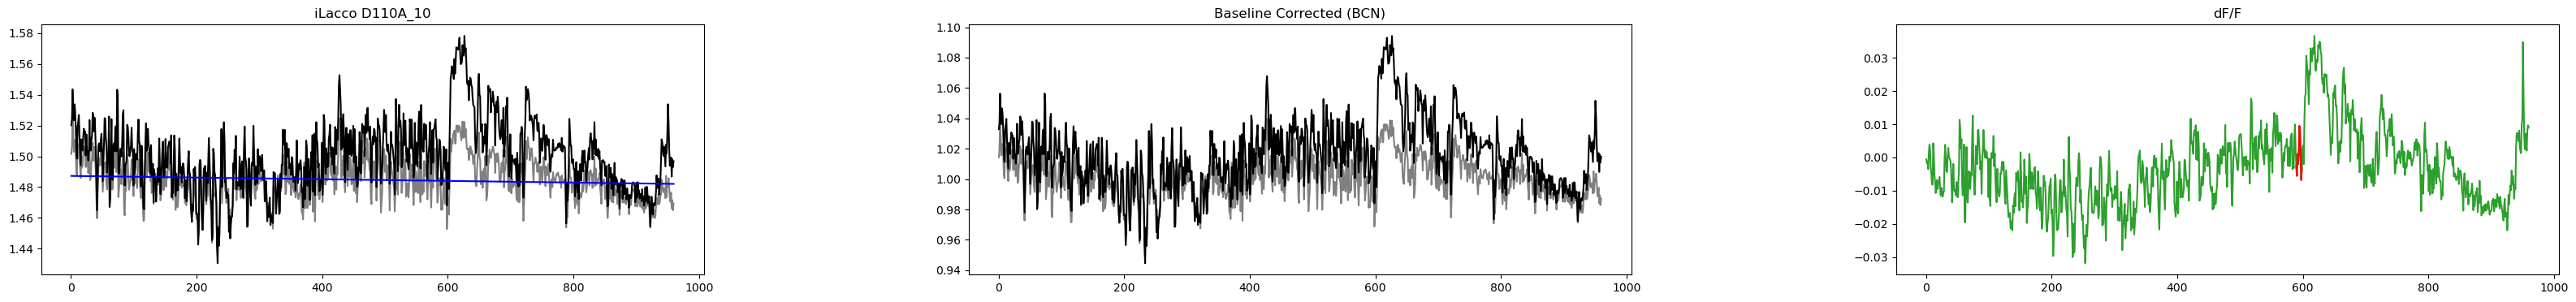

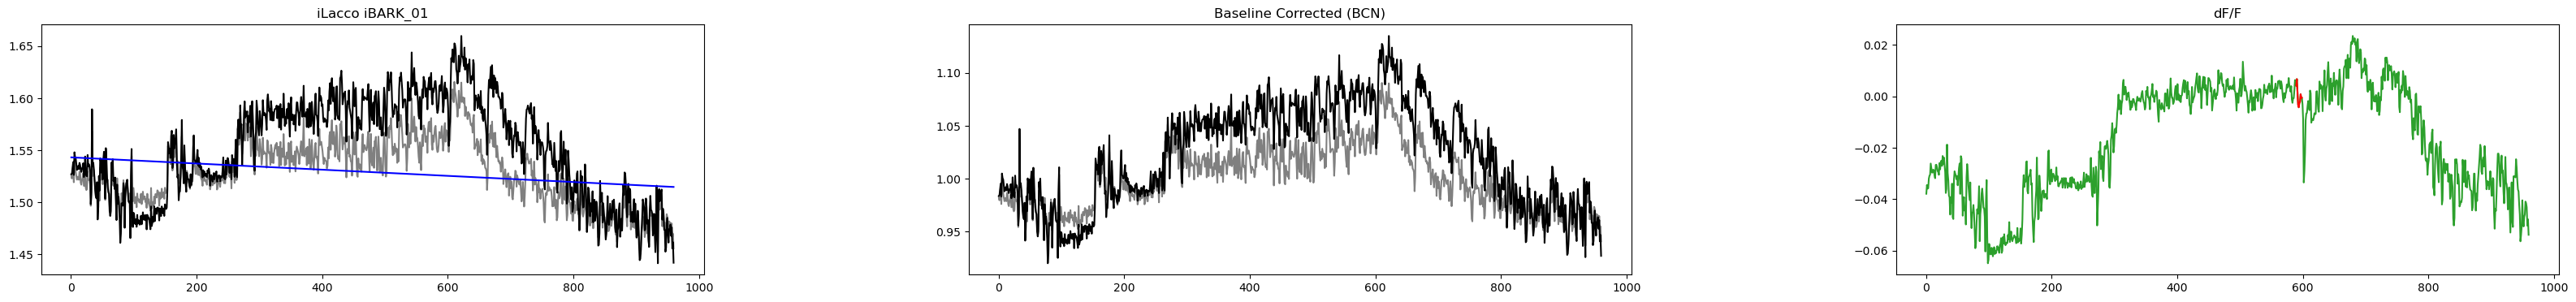

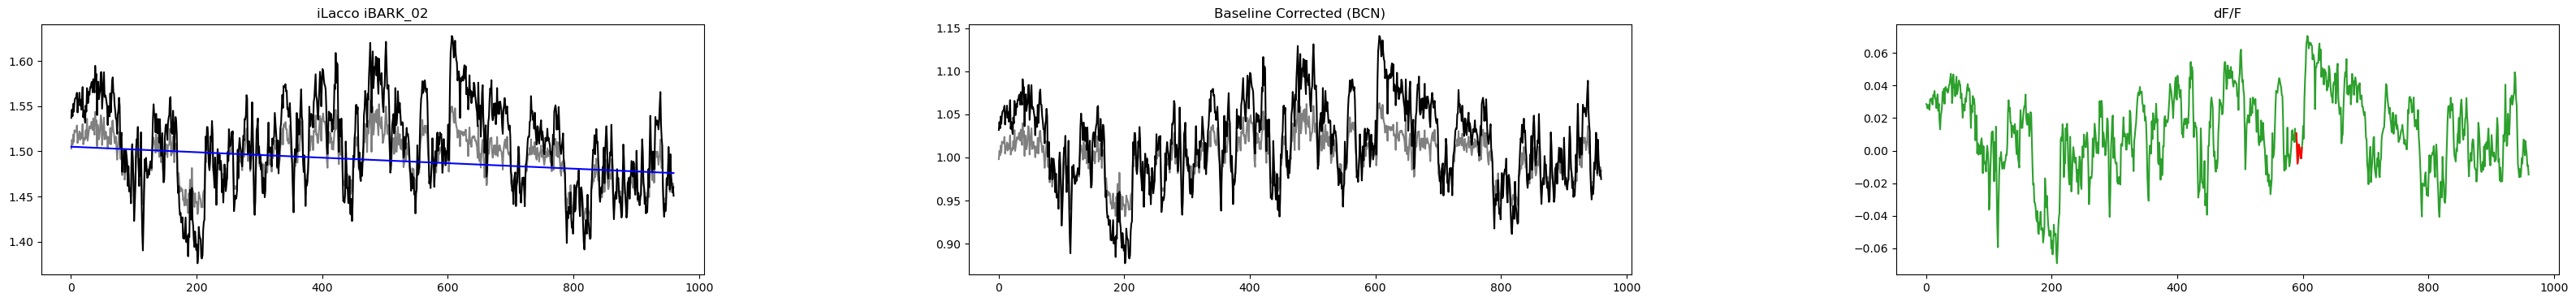

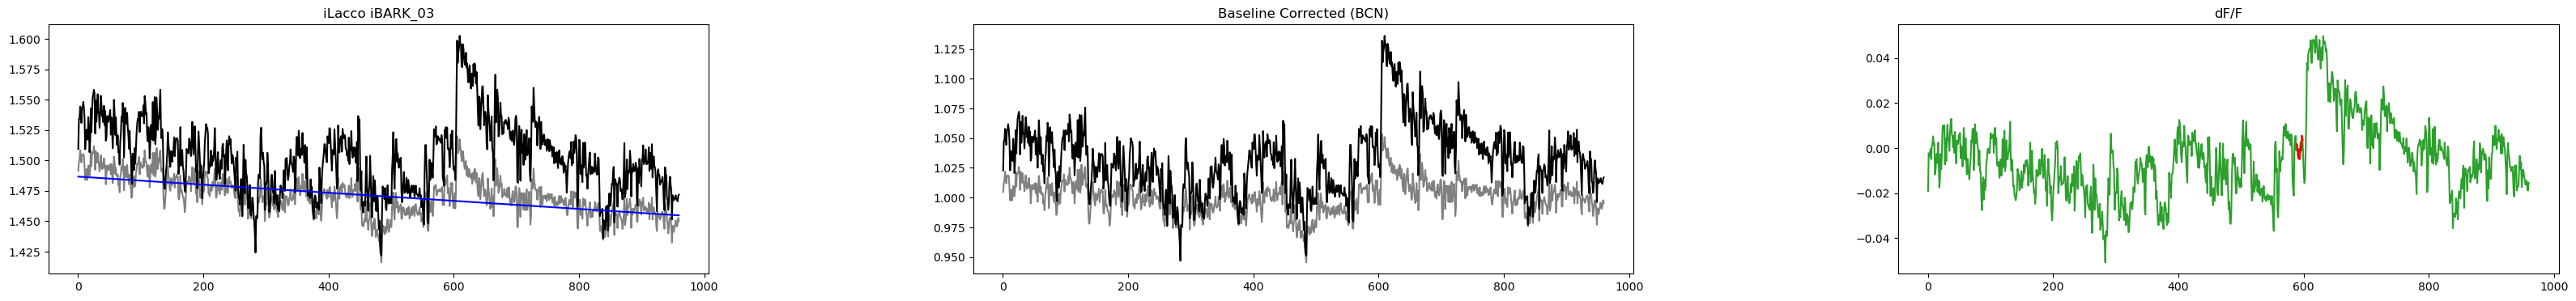

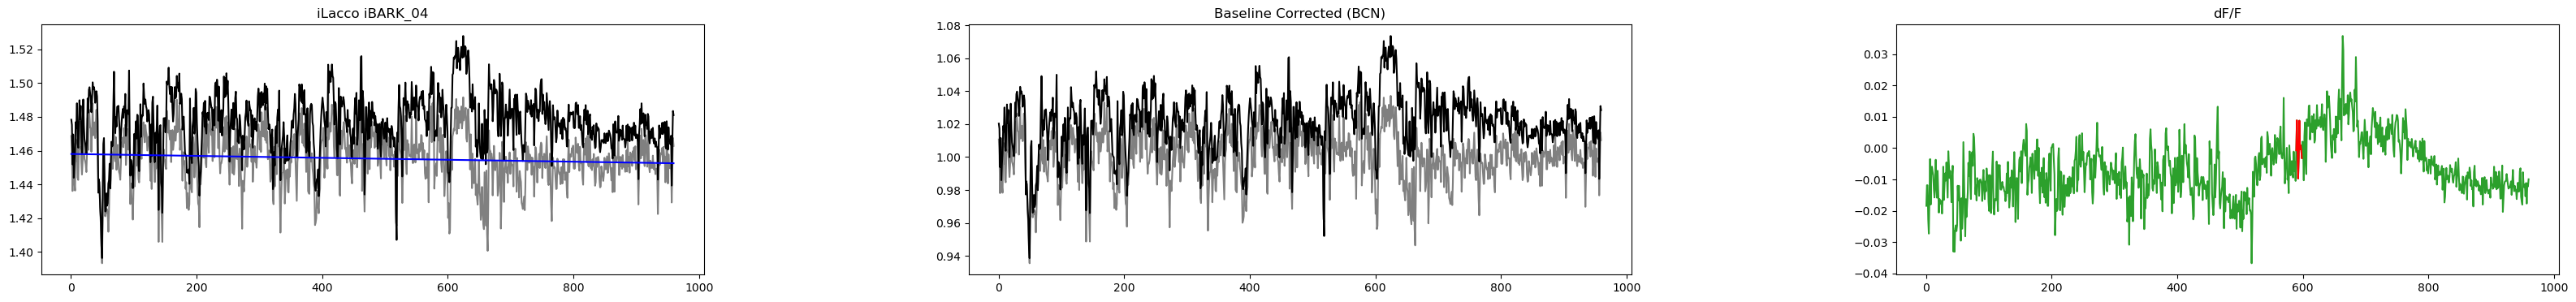

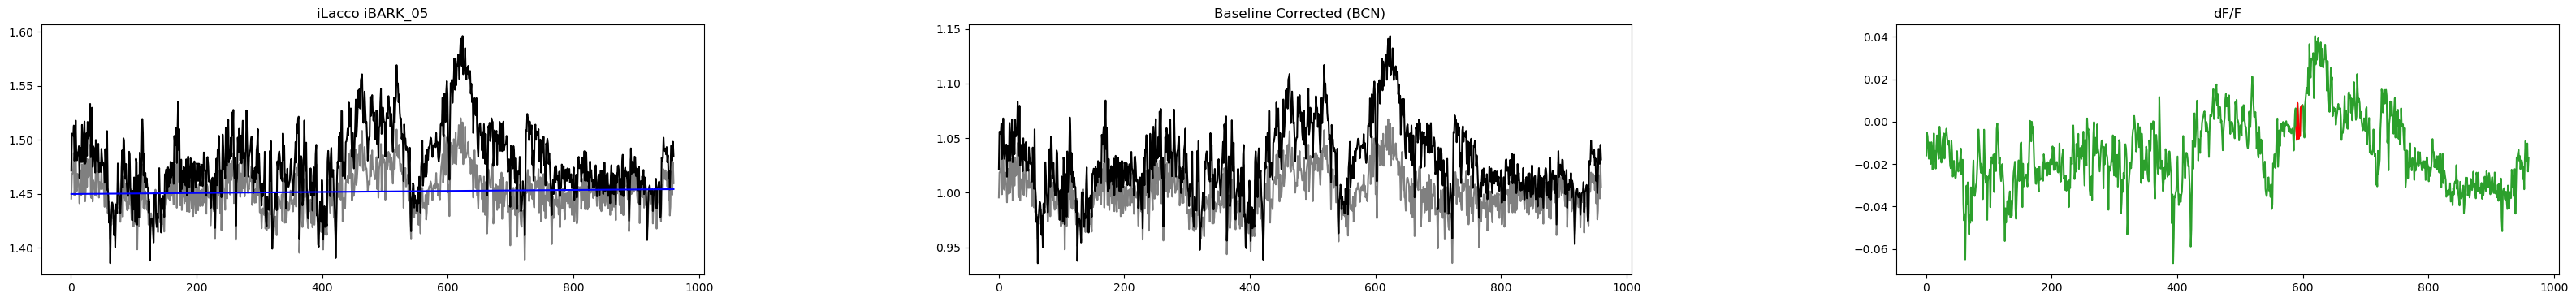

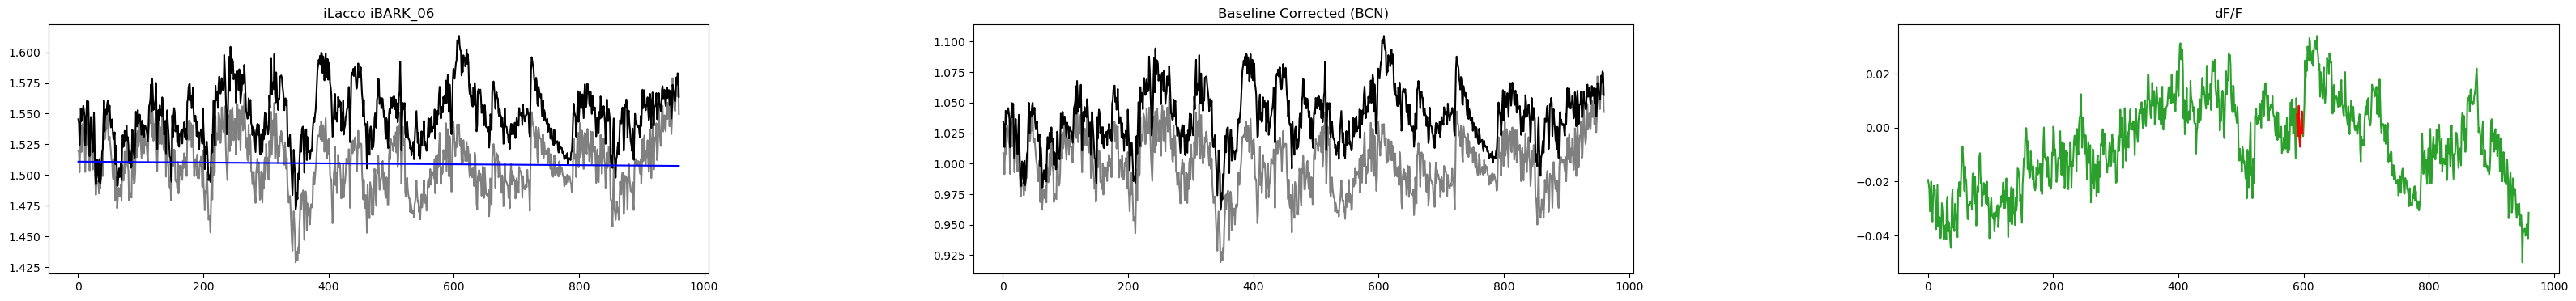

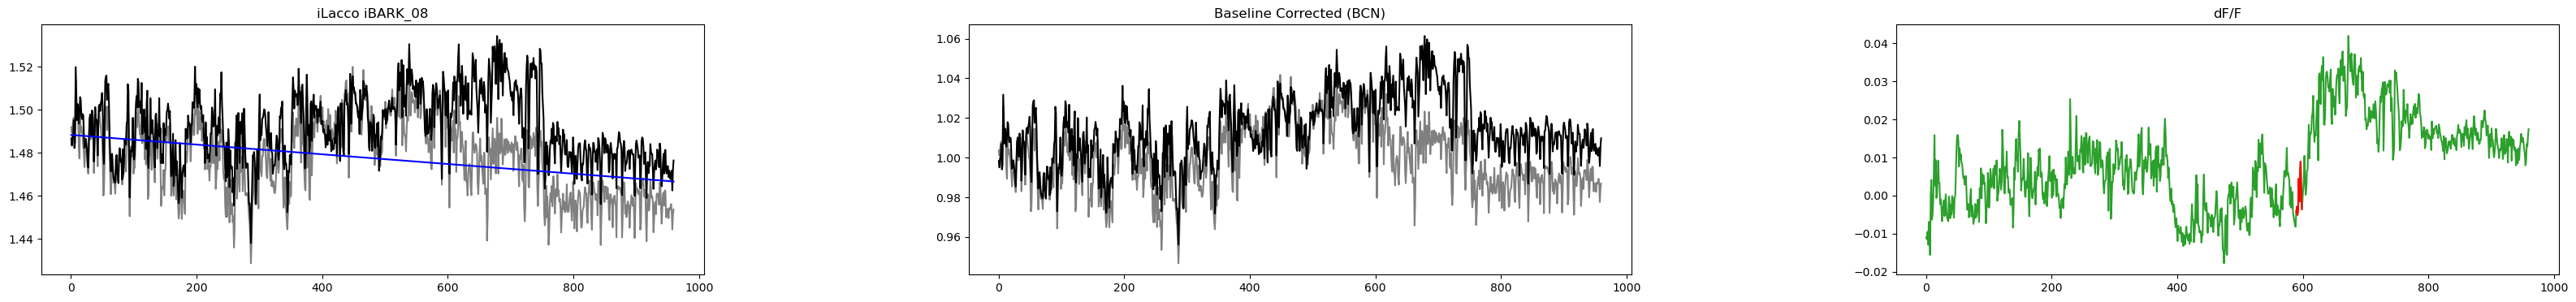

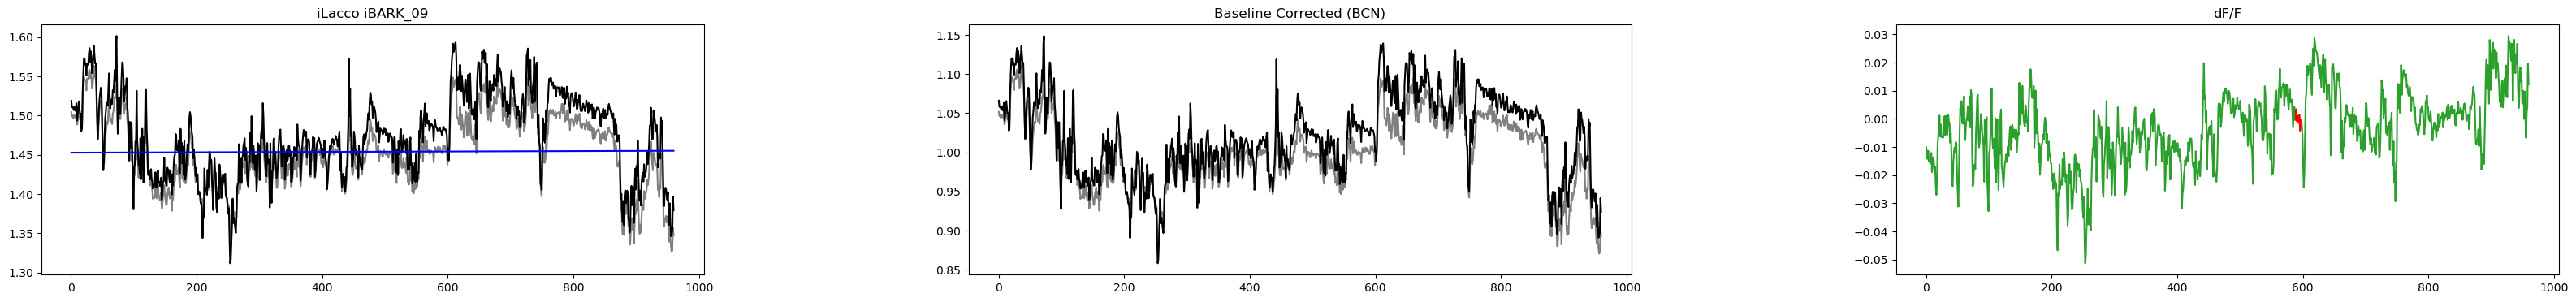

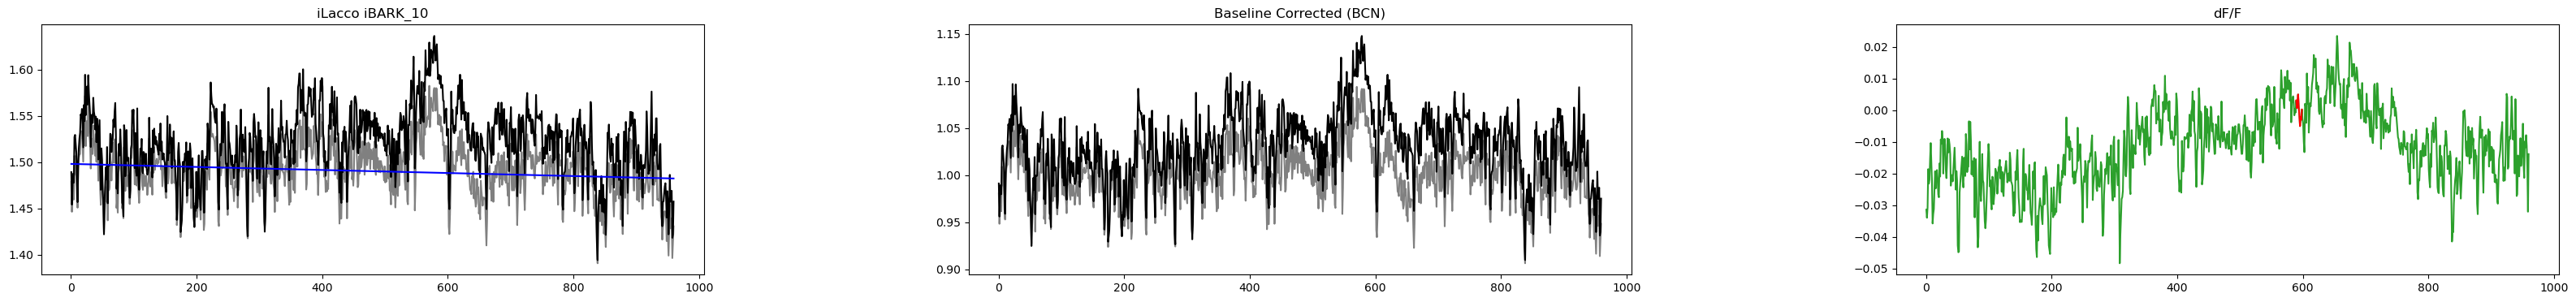

In [24]:
# ==========================================
# 4. Individual dFF Calculation & Plotting (Manual Section)
# ==========================================
# Execute analysis individually by providing custom parameters for each mouse.

# --- D110A Group ---
#D110A_03_iLacco_dFF = dFF_func(D110A_iLacco_movingAve_dict["D110A_03"],0,2040,589,599,0,"iLacco D110A_03")
D110A_iLacco_dFF_dict = {}

for mouse in ["01","03","04","05","06","07", "09", "10"]:
    D110A_iLacco_dFF_dict[f"D110A_{mouse}"] = dFF_func(D110A_iLacco_movingAve_dict[f"D110A_{mouse}"], 0, 2040, 589, 599, 0, f"iLacco D110A_{mouse}")


# --- iBARK グループ ---
#iBARK_01_iLacco_dFF = dFF_func(iBARK_iLacco_movingAve_dict['iBARK_01'], 0, 2040, 500, 510, 0, "iLacco iBARK_01")
iBARK_iLacco_dFF_dict = {}

for mouse in ["01", "02", "03", "04", "05", "06", "08","09", "10"]:
    iBARK_iLacco_dFF_dict[f"iBARK_{mouse}"] = dFF_func(iBARK_iLacco_movingAve_dict[f"iBARK_{mouse}"], 0, 2040, 589, 599, 0, f"iLacco iBARK_{mouse}")


# Figure (whole time)

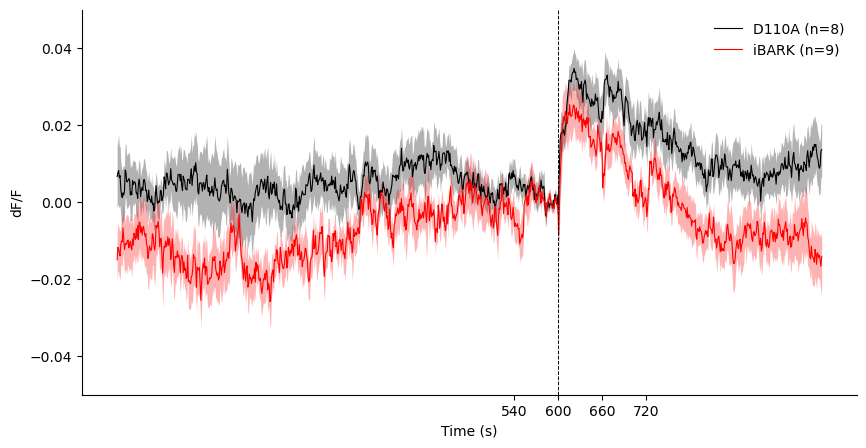

In [25]:
D110A_iLacco_dFF = pd.DataFrame.from_dict(D110A_iLacco_dFF_dict,orient="index")
iBARK_iLacco_dFF = pd.DataFrame.from_dict(iBARK_iLacco_dFF_dict,orient="index")

# Create time axis automatically
time = np.arange(D110A_iLacco_dFF.shape[1])

# Calculate mean and SEM
D110A_iLacco_dFF_mean = D110A_iLacco_dFF.mean()
D110A_iLacco_dFF_sem  = D110A_iLacco_dFF.sem()

iBARK_iLacco_dFF_mean = iBARK_iLacco_dFF.mean()
iBARK_iLacco_dFF_sem  = iBARK_iLacco_dFF.sem()

plt.figure(figsize=(10,5))

# D110A
plt.fill_between( time, D110A_iLacco_dFF_mean - D110A_iLacco_dFF_sem, D110A_iLacco_dFF_mean + D110A_iLacco_dFF_sem, color="black", alpha=0.3, lw=0)
plt.plot( time, D110A_iLacco_dFF_mean, color="black", lw=0.8, label=f"D110A (n={D110A_iLacco_dFF.shape[0]})")

# iBARK
plt.fill_between( time, iBARK_iLacco_dFF_mean - iBARK_iLacco_dFF_sem,  iBARK_iLacco_dFF_mean + iBARK_iLacco_dFF_sem, color="red", alpha=0.3, lw=0)
plt.plot(time,iBARK_iLacco_dFF_mean, color="red", lw=0.8, label=f"iBARK (n={iBARK_iLacco_dFF.shape[0]})")
plt.axvline(x=600, color="black", linestyle="--", linewidth=0.7)

plt.xlabel("Time (s)")
plt.ylabel("dF/F")
plt.ylim(-0.05, 0.05)
plt.xticks([540, 600, 660, 720])

plt.legend(frameon=False)

plt.gca().spines["right"].set_visible(False)
plt.gca().spines["top"].set_visible(False)

plt.show()

# 0-6 min

In [26]:
D110A_iLacco_dFF_6min_dict = {}
iBARK_iLacco_dFF_6min_dict = {}

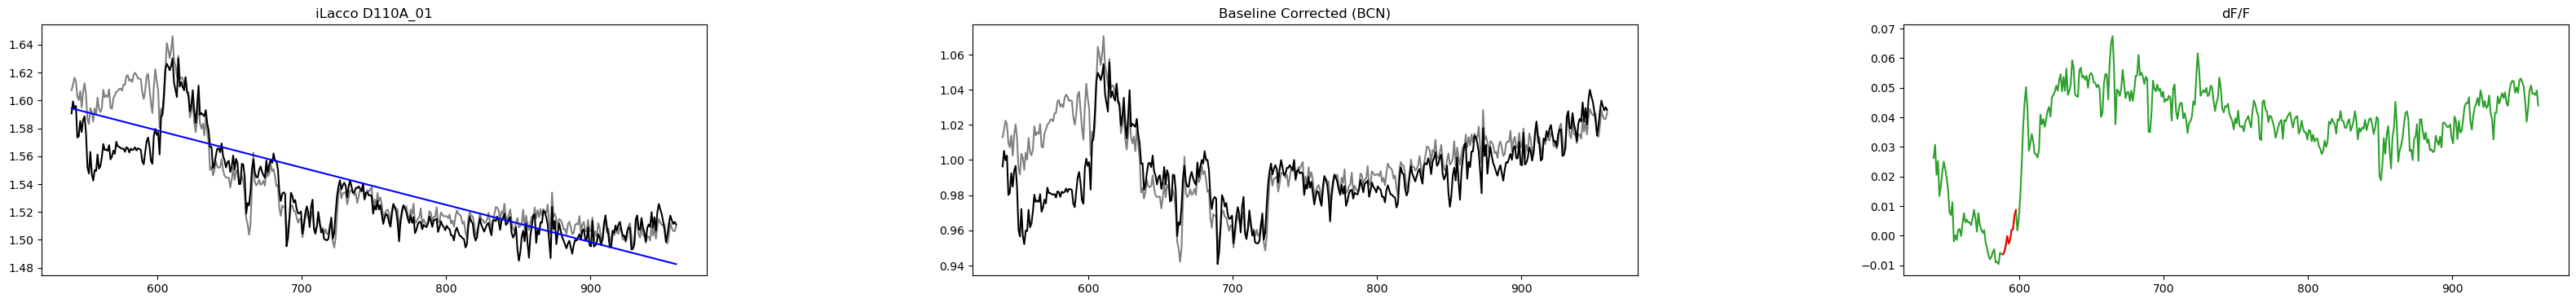

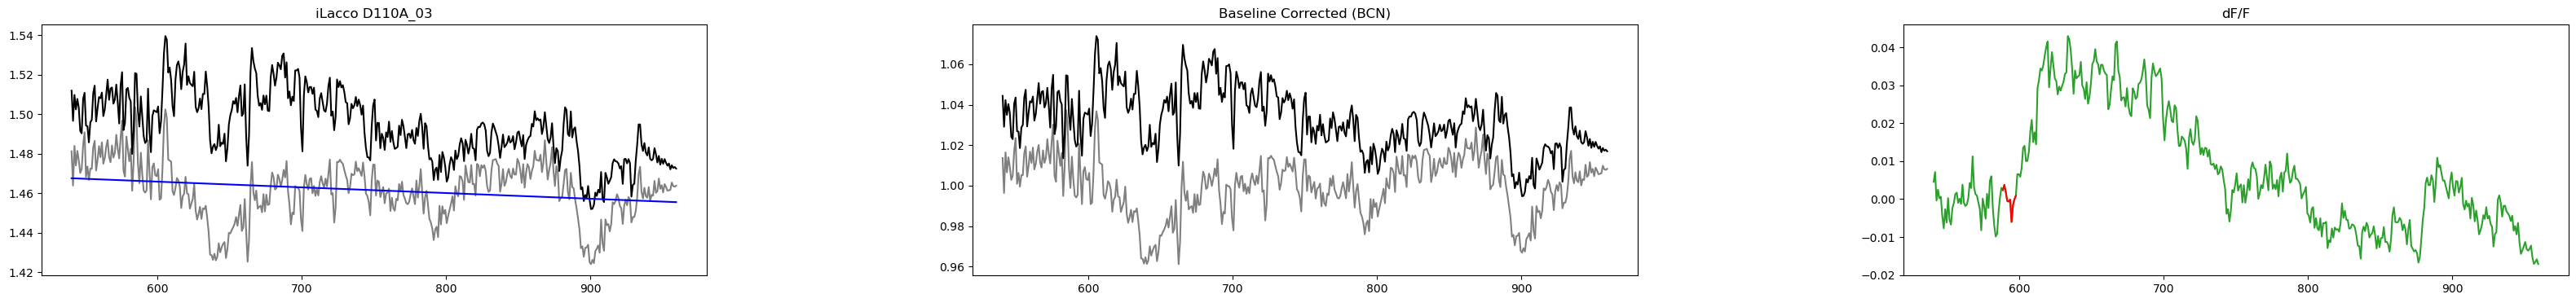

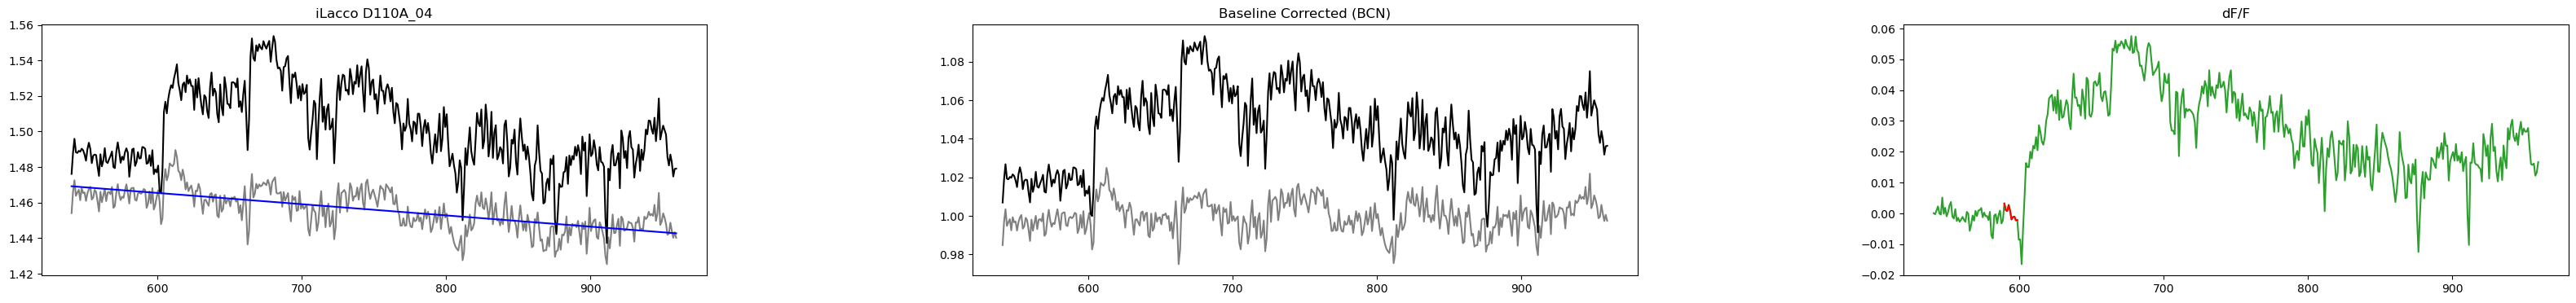

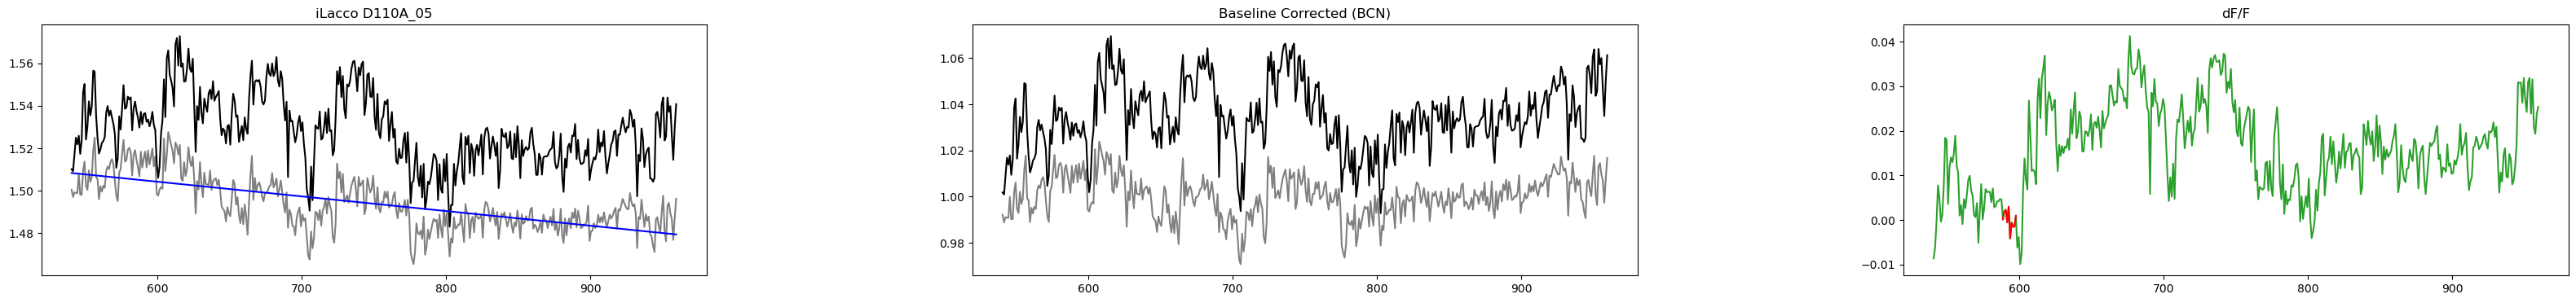

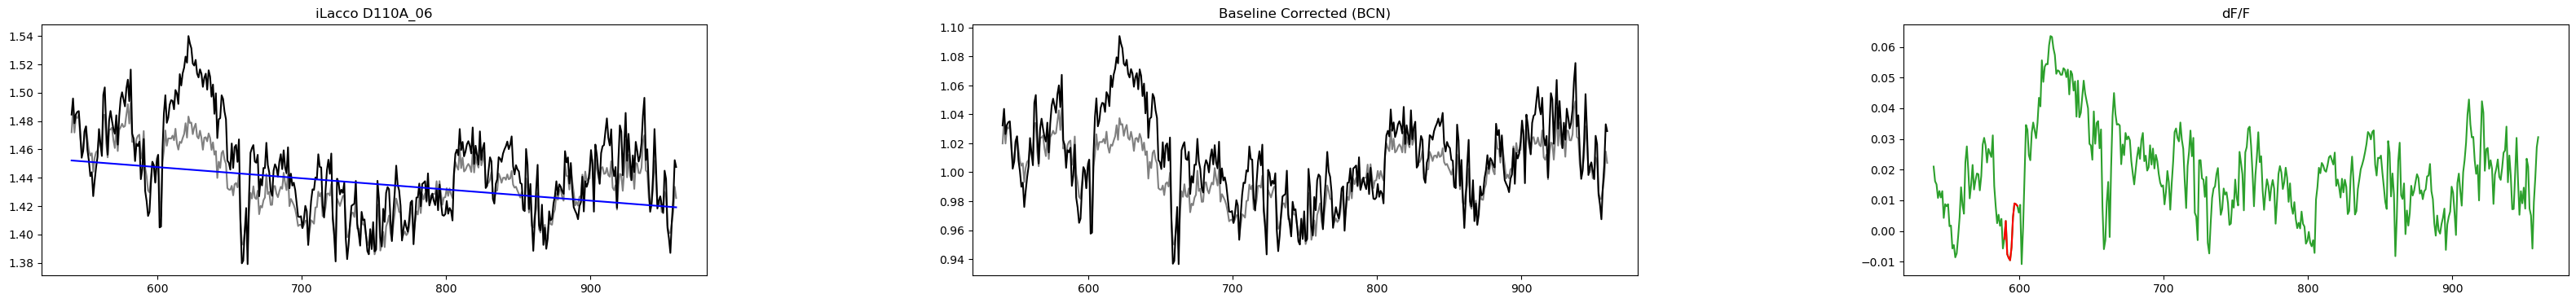

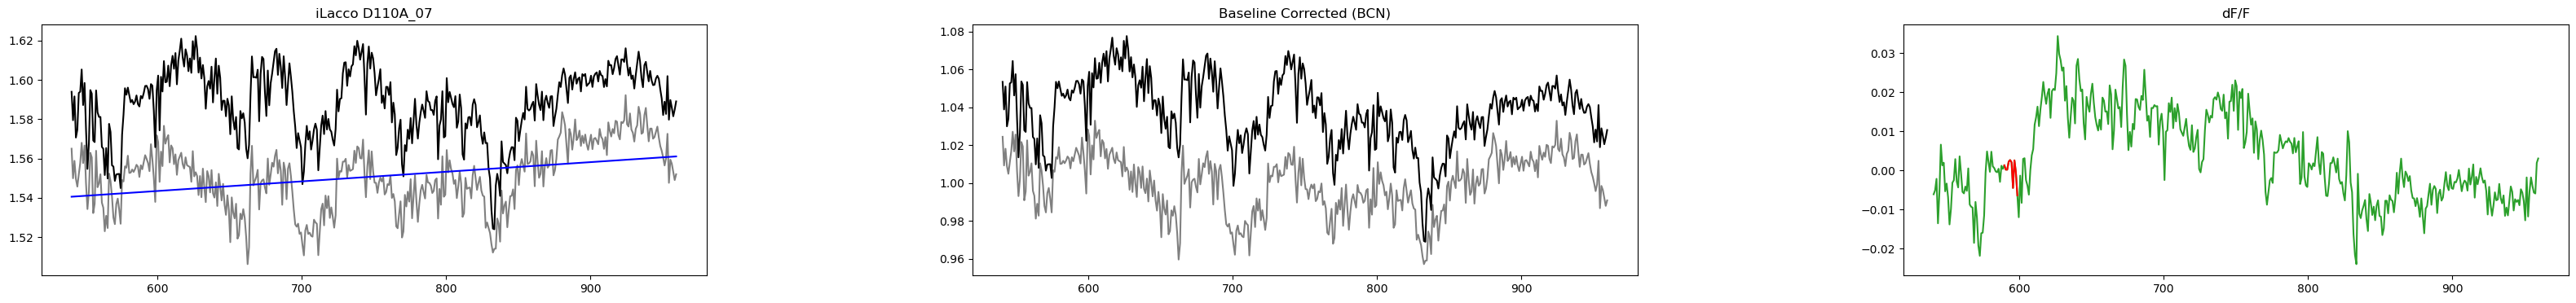

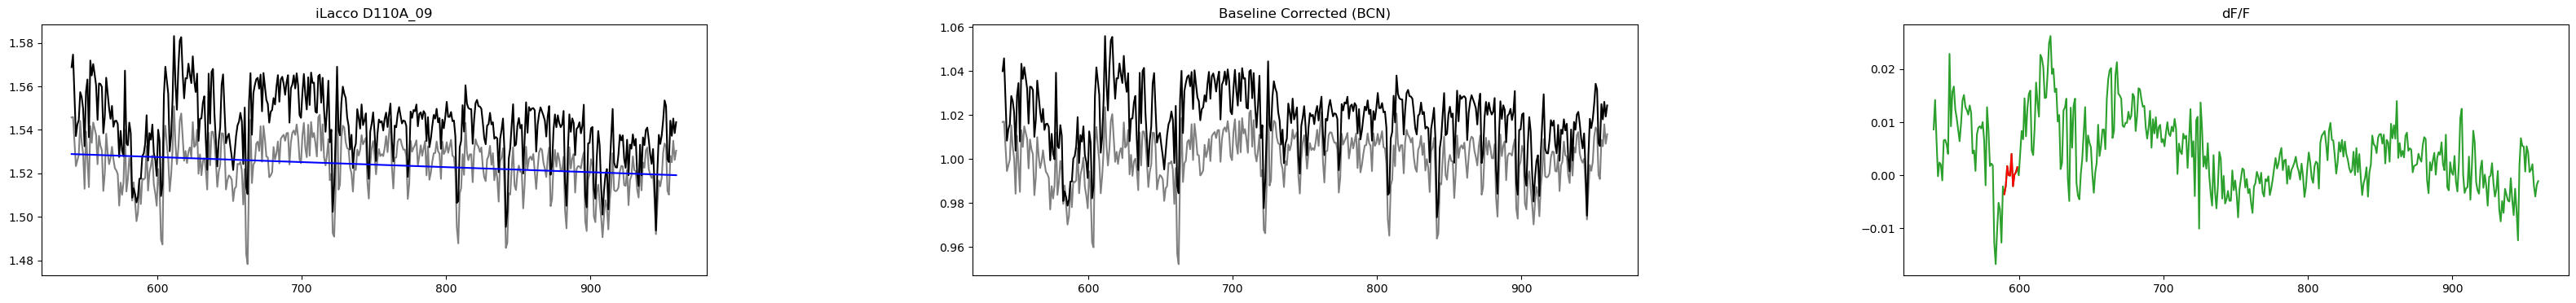

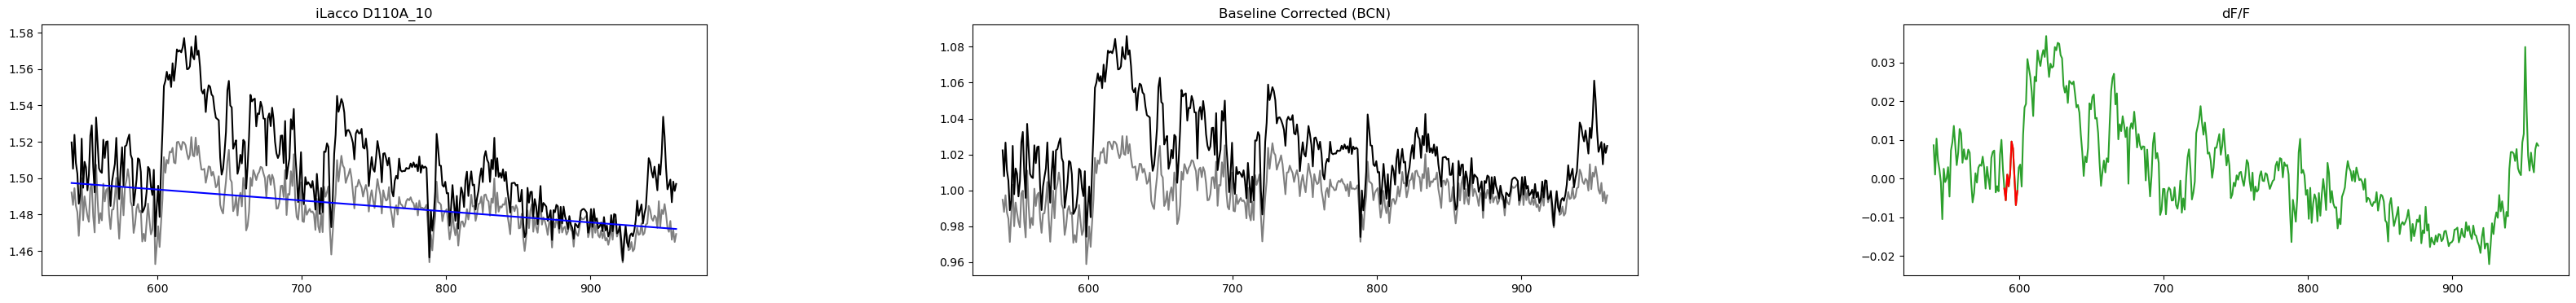

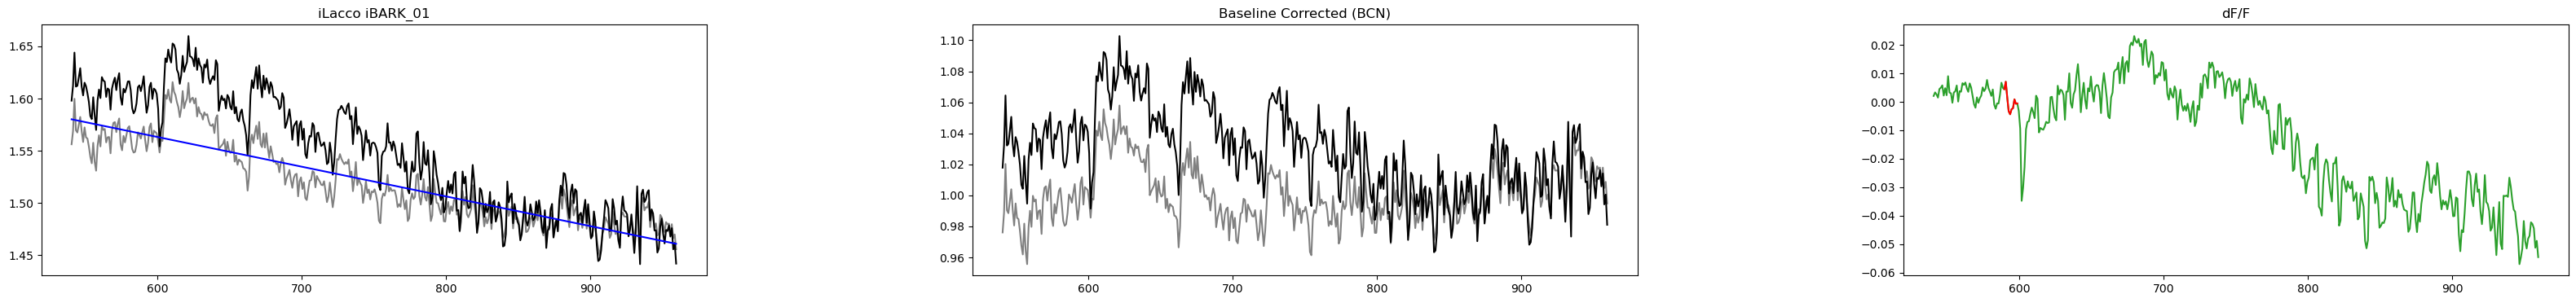

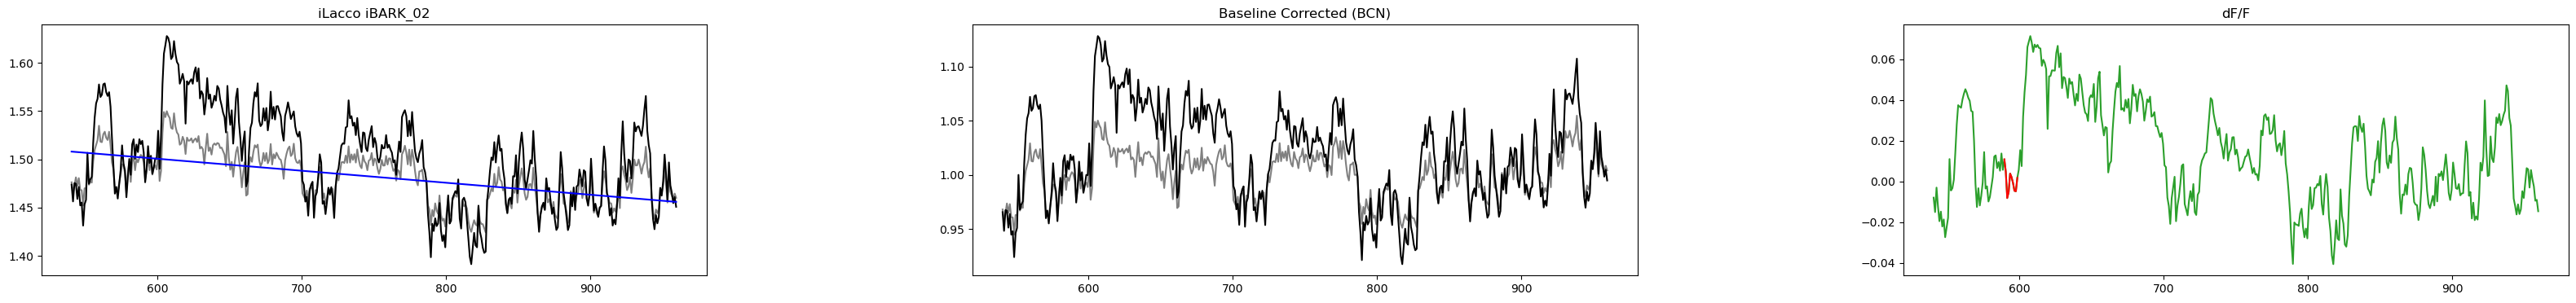

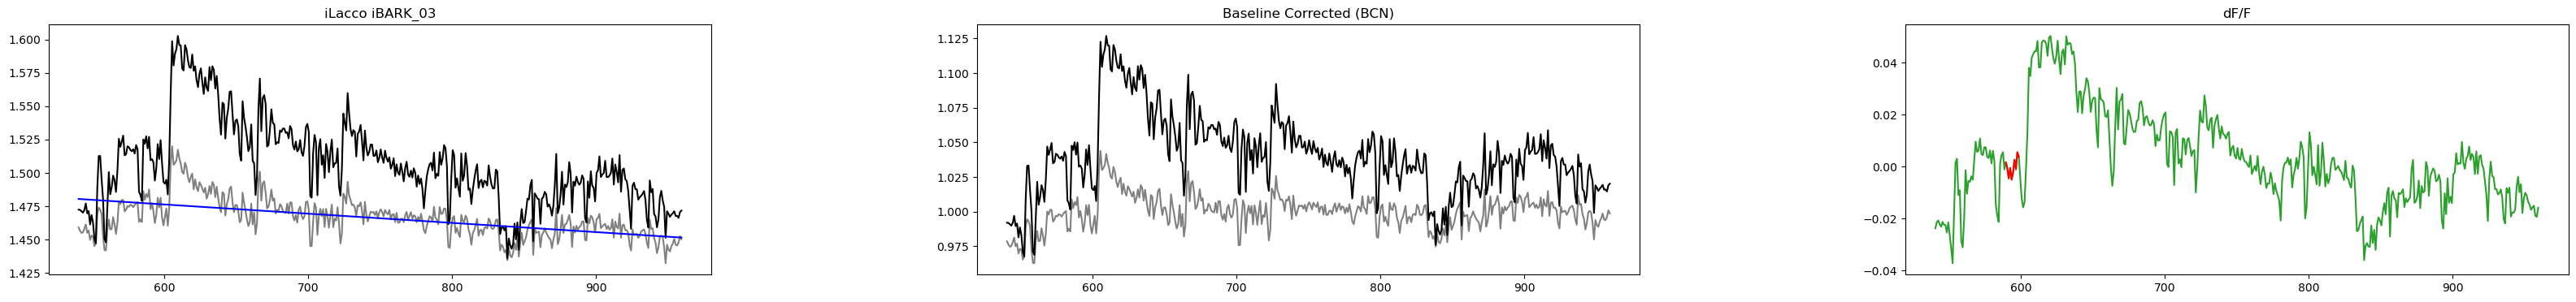

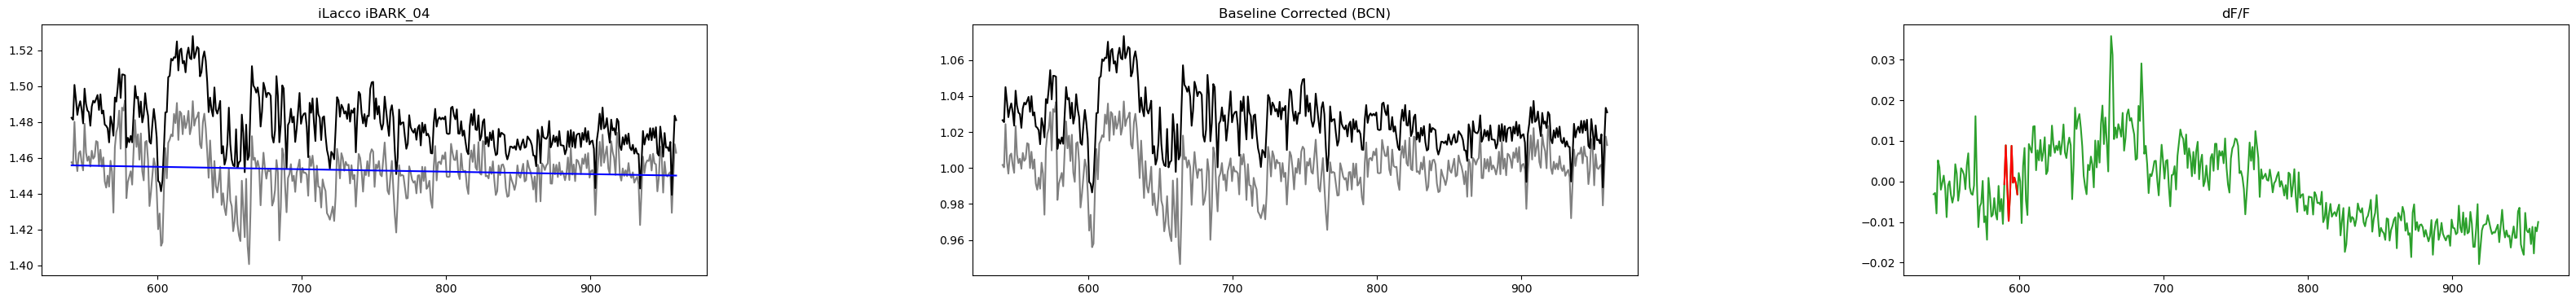

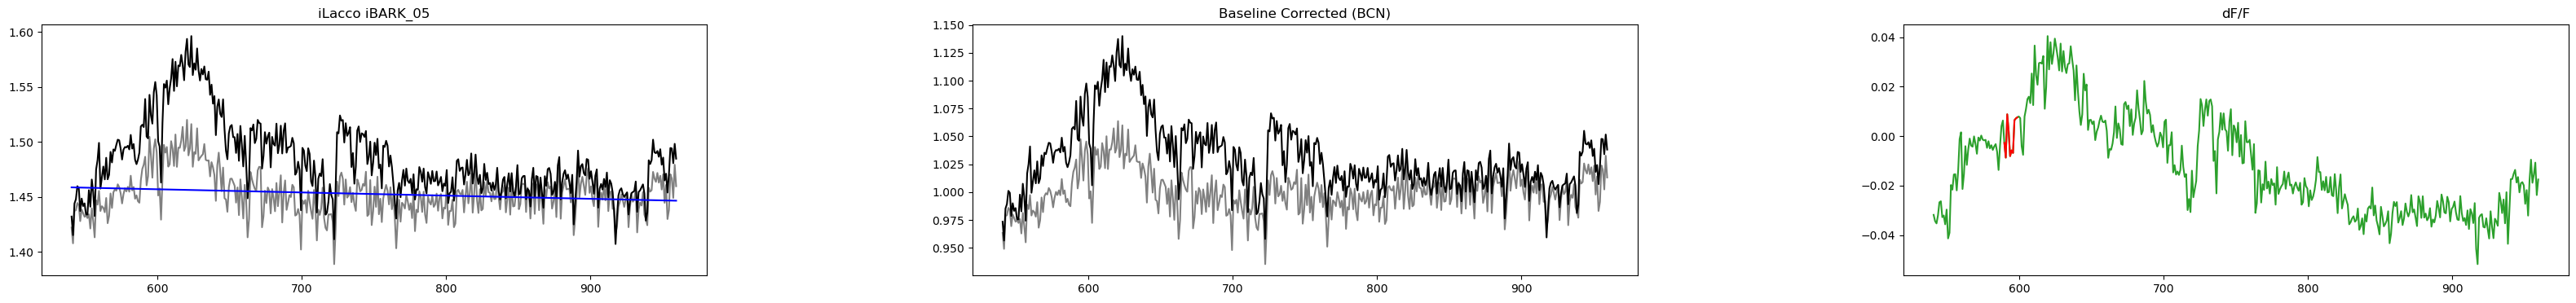

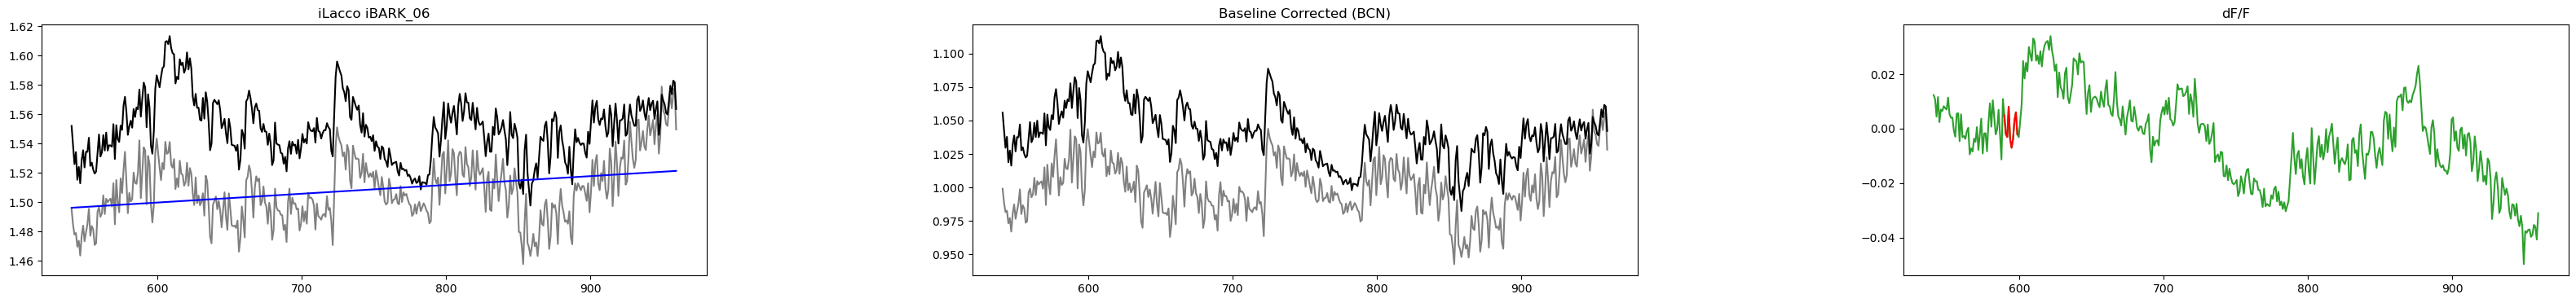

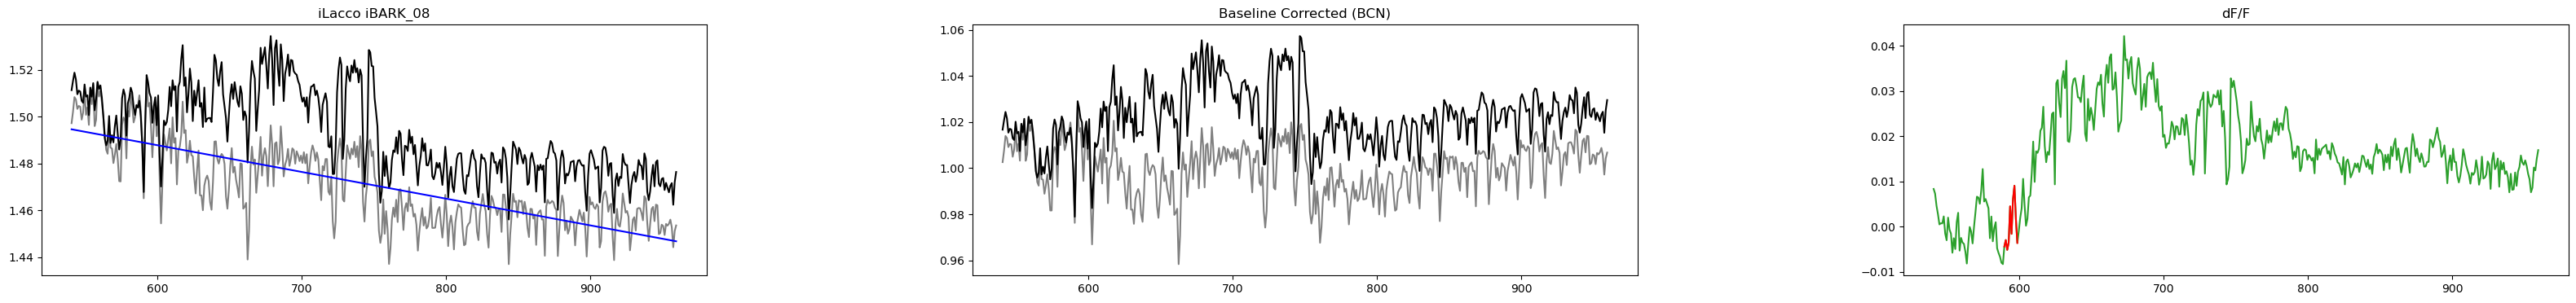

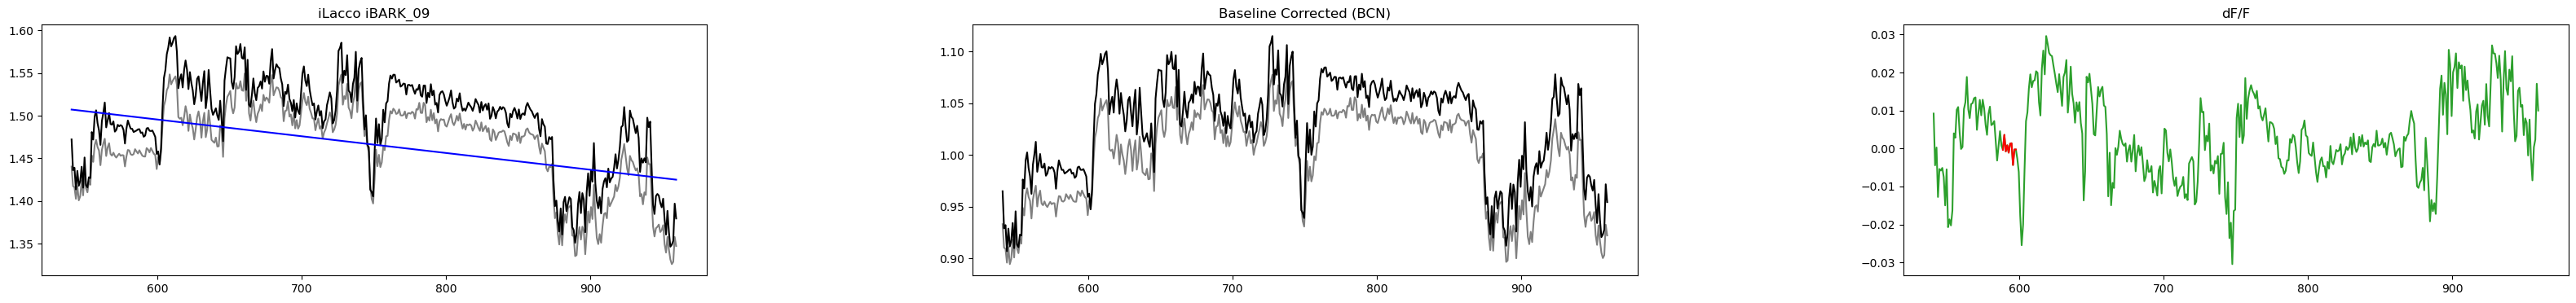

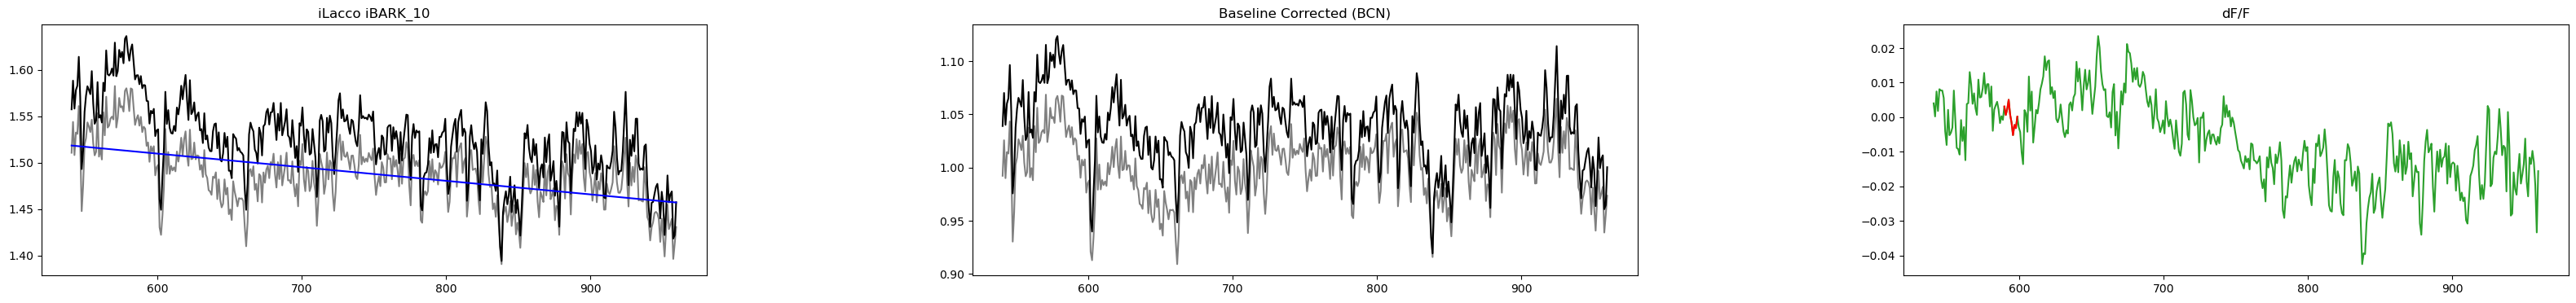

In [27]:
for mouse in ["01","03","04","05","06","07", "09", "10"]:
    D110A_iLacco_dFF_6min_dict[f"D110A_{mouse}"] = dFF_func(D110A_iLacco_movingAve_dict[f"D110A_{mouse}"].iloc[540:], 0, 2040, 589, 599, 0, f"iLacco D110A_{mouse}")
    
for mouse in ["01", "02", "03", "04", "05", "06", "08","09", "10"]:
    iBARK_iLacco_dFF_6min_dict[f"iBARK_{mouse}"] = dFF_func(iBARK_iLacco_movingAve_dict[f"iBARK_{mouse}"].iloc[540:], 0, 2040, 589, 599, 0, f"iLacco iBARK_{mouse}")

# Figure (0-6 min)

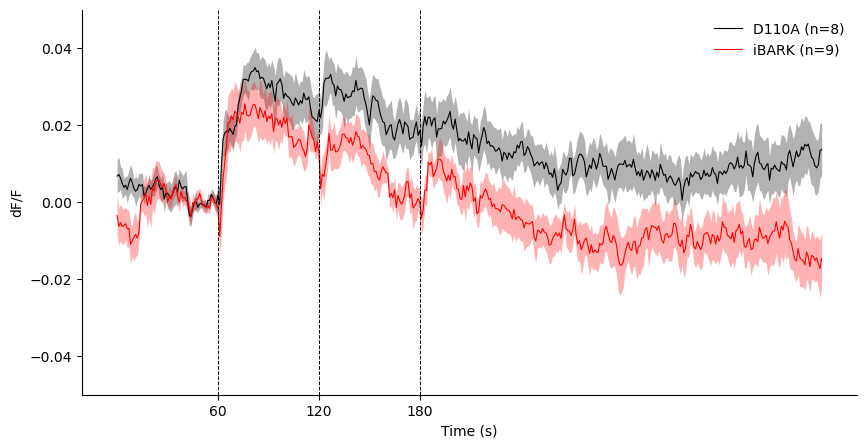

In [28]:
D110A_iLacco_dFF = pd.DataFrame.from_dict(D110A_iLacco_dFF_6min_dict,orient="index")
iBARK_iLacco_dFF = pd.DataFrame.from_dict(iBARK_iLacco_dFF_6min_dict,orient="index")

# Create time axis automatically
time = np.arange(D110A_iLacco_dFF.shape[1])

# Calculate mean and SEM
D110A_iLacco_dFF_mean = D110A_iLacco_dFF.mean()
D110A_iLacco_dFF_sem  = D110A_iLacco_dFF.sem()

iBARK_iLacco_dFF_mean = iBARK_iLacco_dFF.mean()
iBARK_iLacco_dFF_sem  = iBARK_iLacco_dFF.sem()

plt.figure(figsize=(10,5))

# D110A
plt.fill_between( time, D110A_iLacco_dFF_mean - D110A_iLacco_dFF_sem, D110A_iLacco_dFF_mean + D110A_iLacco_dFF_sem, color="black", alpha=0.3, lw=0)
plt.plot( time, D110A_iLacco_dFF_mean, color="black", lw=0.8, label=f"D110A (n={D110A_iLacco_dFF.shape[0]})")

# iBARK
plt.fill_between( time, iBARK_iLacco_dFF_mean - iBARK_iLacco_dFF_sem,  iBARK_iLacco_dFF_mean + iBARK_iLacco_dFF_sem, color="red", alpha=0.3, lw=0)
plt.plot(time,iBARK_iLacco_dFF_mean, color="red", lw=0.8, label=f"iBARK (n={iBARK_iLacco_dFF.shape[0]})")
plt.axvline(x=60, color="black", linestyle="--", linewidth=0.7)
plt.axvline(x=120, color="black", linestyle="--", linewidth=0.7)
plt.axvline(x=180, color="black", linestyle="--", linewidth=0.7)

plt.xlabel("Time (s)")
plt.ylabel("dF/F")
plt.ylim(-0.05, 0.05)
plt.xticks([60, 120, 180])

plt.legend(frameon=False)

plt.gca().spines["right"].set_visible(False)
plt.gca().spines["top"].set_visible(False)

plt.show()